In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Load in data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## Summary Statistcs

- `sum()` : sum values in each column
- `count()` : count non-NA values in each column
- `size()` : count the number of values in a column (including NA values)
- `min()` and `max()` : get the minimum and maximum value in each column
- `mean()` and `median()` : get the mean and median vallue in each column
- `std()` and `var()` : get the standard deviation and variance in each column

In [5]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [6]:
# Get the minimum value in each column with numberical values 
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

## Grouping

the split-apply-combine strategy is where we start with species, split the original table to group all observations of the same species together, calculate desired summary statistic for each of the groups that were formed and then we combine values for average flipper length per species into a single table.

- split: the data into logical groups
- apply: calculate some summary statistic on each group
- combine: combine the statistc calculated on each group back together

for pandas.DataFrame or pandas.Series we can use the `groupby()` function to split the data into different groups

``` general syntax
General syntax
df.groupby(columns to group by).summary_method()
```

In [7]:
# Example - incorrect because we obtain the average of all the value in the column
penguins['flipper_length_mm'].mean()

200.91520467836258

In [8]:
# Example - incorrect because we do not specify what we wish to calculate
penguins.groupby('species')['flipper_length_mm']

In [9]:
# Average flipper length per species
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

## Recap
1. start with the penguins dataframe and then...
2. use `groupby()` to group the data frame by `species` values and then...
3. select the `flipper_length_mm` column and then...
4. calculate the `mean()` of this column with respect to the groups

In [10]:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')['flipper_length_mm']
    .mean()
    .rename('mean_flipper_length')
    .sort_values(ascending = False))

avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [11]:
# we can also group by combinations of columns
# Example

# Average flipper length per species and island
avg_flipper_species_island = (penguins.groupby(['species', 'island'])['flipper_length_mm']
    .mean().rename('mean_flipper_length').sort_values(ascending = False))

avg_flipper_species_island

species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

## Grouping and NA values

Notice first that 11 penguins have no recorded sex. We can check this by using: 

- `size()` : returns the number of observations in a pandas.Series
- `count()` : reutrns the number of non-NA observations in the series

In [12]:
# Number of NA observations
penguins['sex'].size - penguins['sex'].count()

11

In [13]:
# by default `groupby()` leaves out the rows where the grouping column has Na values. 
# When we group by `sex` and count the number of observations (rows) we are left with, 11 NA values are not included.

penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [14]:
# To keep the NA values as their own group, we use the `dropna = False` parameter

In [15]:
penguins.groupby('sex', dropna = False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check Ins

We want to know the number of pnguins suveyeed on each island in different years.

In [16]:
# Step 1. Run:
penguins.groupby(['island', 'year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island    year                                                              
Biscoe    2007       44              44             44                 44   
          2008       64              64             64                 64   
          2009       60              59             59                 59   
Dream     2007       46              46             46                 46   
          2008       34              34             34                 34   
          2009       44              44             44                 44   
Torgersen 2007       20              19             19                 19   
          2008       16              16             16                 16   
          2009       16              16             16                 16   

                body_mass_g  sex  
island    year                    
Biscoe    2007           44   43  
          2008           64   63  
          2009           59   57  
Dream     2007           46   45  
          2008           34   34  
          2009           44   44  
Torgersen 2007           19   15  
          2008           16   16  
          2009           16   16

In [17]:
# and:
penguins.groupby(['island', 'year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

Based on both outputs, `.size()` gives a Series with the number of penguins surveyed on each island and year combination, because it counts every row, including those with missing values. While `.count()` returns a DataFrame and counts non-missing values column by column, so its counts can differ between columns

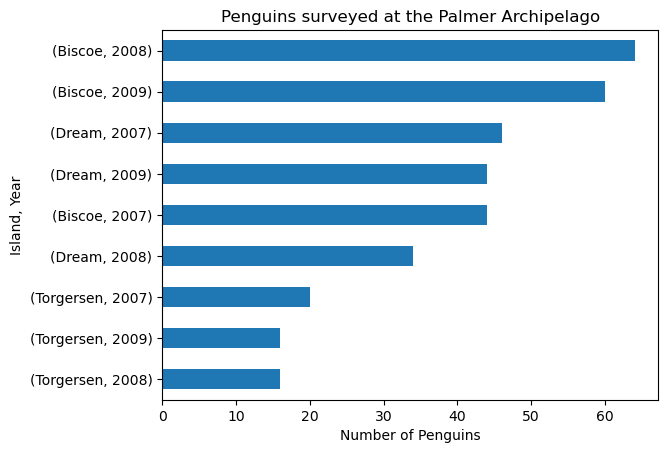

In [19]:
# Now lets plot the surveyed population per year and island

(penguins.groupby(['island', 'year']).size().sort_values().plot(kind = 'barh', title = 'Penguins surveyed at the Palmer Archipelago',
                                                              xlabel = 'Number of Penguins',
                                                              ylabel = 'Island, Year'))
plt.show()

## Check in

1. Use the `max()` method to calculate the maximum value of a penguins body mass by year and species

In [24]:
max_body_mass = (penguins.groupby(['year', 'species'])['body_mass_g'].max())
max_body_mass

year  species  
2007  Adelie       4675.0
      Chinstrap    4400.0
      Gentoo       6300.0
2008  Adelie       4700.0
      Chinstrap    4800.0
      Gentoo       6000.0
2009  Adelie       4775.0
      Chinstrap    4450.0
      Gentoo       6000.0
Name: body_mass_g, dtype: float64

2. Use (1) to display the highest body masses per year and species as a bar plot in descending order

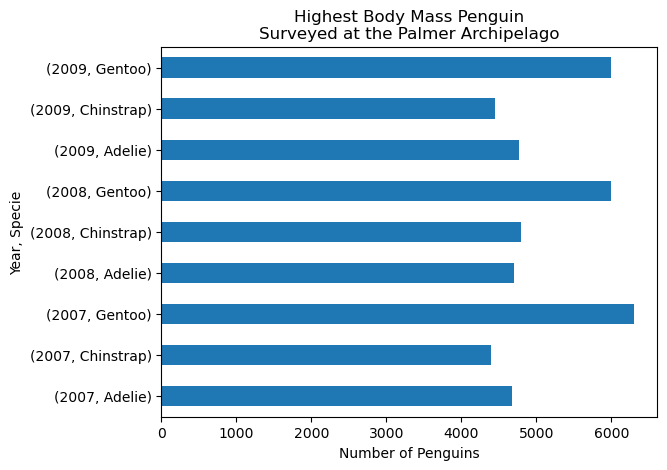

In [30]:
max_body_mass.plot(
    kind = 'barh', 
    title = 'Highest Body Mass Penguin\nSurveyed at the Palmer Archipelago', 
    xlabel = 'Number of Penguins', 
    ylabel = 'Year, Specie')

plt.show()